In [ ]:
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from '/Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Dissertation/.venv/lib/python3.14/site-packages/pandas/__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)
/Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Dissertation/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_path   = "driftDatasets/artificial/hyperplane/rotatingHyperplane.data"
labels_path = "driftDatasets/artificial/hyperplane/rotatingHyperplane.labels"

X = np.loadtxt(data_path)            # features: a table, one row per instance
y = np.loadtxt(labels_path).astype(int)  # labels: 0 or 1, one per instance

print("Feature table shape:", X.shape)   # (rows, columns) = (instances, features)
print("Labels shape:", y.shape)

Feature table shape: (200000, 10)
Labels shape: (200000,)


In [4]:
print("First 3 rows of features:\n", X[:3])
print("\nNumber of features:", X.shape[1])
print("First 10 labels:", y[:10])
print("Class balance:", np.bincount(y))   # how many of each class

First 3 rows of features:
 [[0.397174 0.347518 0.294057 0.506484 0.115967 0.770536 0.659893 0.156747
  0.378202 0.139763]
 [0.27503  0.075388 0.610592 0.954931 0.274069 0.190202 0.001299 0.683527
  0.48626  0.487515]
 [0.233156 0.889909 0.038327 0.592379 0.655174 0.119839 0.652477 0.984323
  0.206738 0.37465 ]]

Number of features: 10
First 10 labels: [0 0 1 0 0 0 1 0 1 1]
Class balance: [100065  99935]


In [5]:
def mean_abs_shap(shap_values, n_features):
    sv = np.abs(np.array(shap_values))
    # find the axis whose length equals the number of features, average over the rest
    feat_axis = [ax for ax, size in enumerate(sv.shape) if size == n_features][-1]
    other_axes = tuple(ax for ax in range(sv.ndim) if ax != feat_axis)
    return sv.mean(axis=other_axes)   # -> one importance number per feature

In [6]:
def windowed_importance(X, y, window=1000, sample=200, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    n_windows = n // window

    importances, fixed_acc, centers = [], [], []
    fixed_model = None   # the model trained only on window 0, then never updated

    for w in range(n_windows):
        lo, hi = w * window, (w + 1) * window
        Xw, yw = X[lo:hi], y[lo:hi]
        if len(np.unique(yw)) < 2:        # skip a window with only one class
            continue

        # 1) train a model on THIS window's concept
        clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=seed)
        clf.fit(Xw, yw)

        # 2) measure feature importance with SHAP (on a subsample for speed)
        m = min(sample, len(Xw))
        idx = rng.choice(len(Xw), m, replace=False)
        sv = shap.TreeExplainer(clf).shap_values(Xw[idx])
        imp = mean_abs_shap(sv, d)
        importances.append(imp / imp.sum())   # normalise so the window sums to 1 (shares)
        centers.append((lo + hi) // 2)        # time position of this window

        # 3) track the frozen model's accuracy as the stream drifts
        if fixed_model is None:
            fixed_model = clf
            fixed_acc.append(np.nan)           # nothing to compare on window 0
        else:
            fixed_acc.append(fixed_model.score(Xw, yw))

    return np.array(importances), np.array(fixed_acc), np.array(centers)

importances, fixed_acc, centers = windowed_importance(X, y, window=1000)
print("Computed importances for", len(centers), "windows.")

Computed importances for 200 windows.


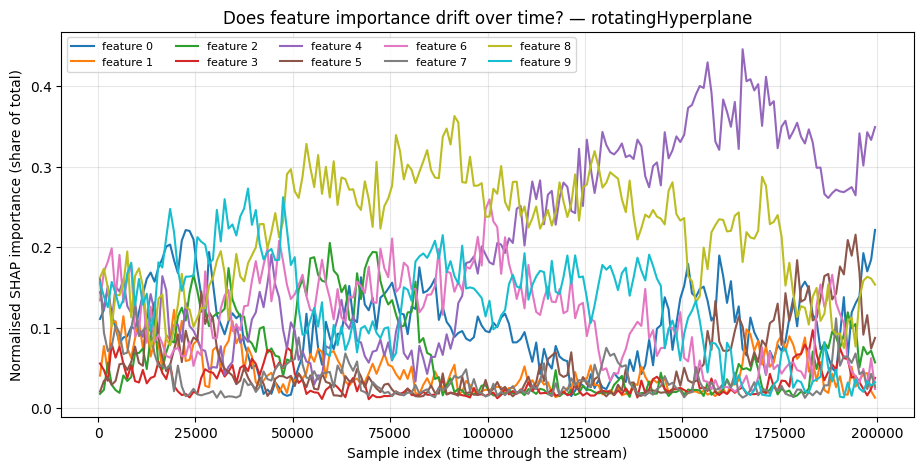

In [7]:
d = X.shape[1]
plt.figure(figsize=(11, 5))
for i in range(d):
    plt.plot(centers, importances[:, i], label=f"feature {i}")
plt.xlabel("Sample index (time through the stream)")
plt.ylabel("Normalised SHAP importance (share of total)")
plt.title("Does feature importance drift over time? — rotatingHyperplane")
plt.legend(ncol=5, fontsize=8)
plt.grid(alpha=0.3)
plt.show()

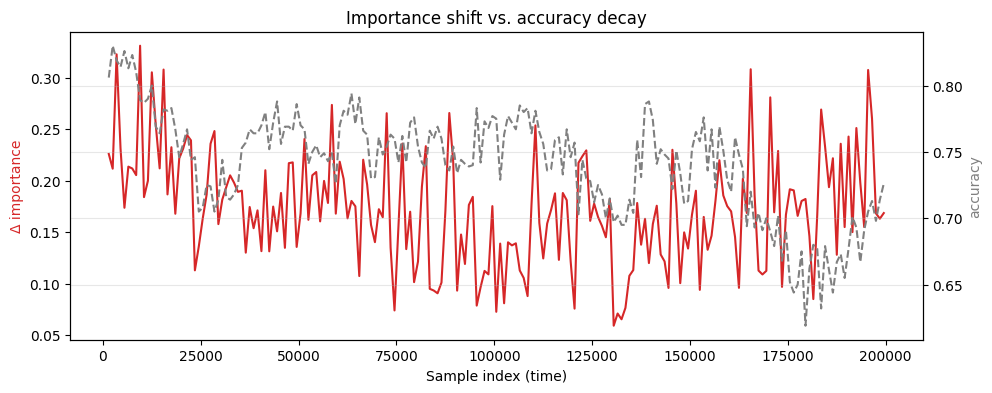

In [8]:
# how much did the importance fingerprint move between consecutive windows?
delta = np.r_[np.nan, np.abs(np.diff(importances, axis=0)).sum(axis=1)]

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(centers, delta, color="tab:red", label="change in importance")
ax1.set_ylabel("Δ importance", color="tab:red")
ax1.set_xlabel("Sample index (time)")

ax2 = ax1.twinx()
ax2.plot(centers, fixed_acc, color="gray", linestyle="--", label="frozen-model accuracy")
ax2.set_ylabel("accuracy", color="gray")
plt.title("Importance shift vs. accuracy decay")
plt.grid(alpha=0.3)
plt.show()

In [9]:
swing = importances.max(axis=0) - importances.min(axis=0)
print("Importance swing per feature:", np.round(swing, 3))
print("Largest swing:", round(swing.max(), 3),
      "(bigger means importance moves more over time)")

Importance swing per feature: [0.207 0.109 0.192 0.086 0.417 0.201 0.239 0.148 0.288 0.26 ]
Largest swing: 0.417 (bigger means importance moves more over time)
